In [ ]:
!pip -q install -U datasets gensim statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 12.7 MB/s eta 0:00:00


In [ ]:
import re
import time
import random
import copy
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence

from datasets import load_dataset
import gensim.downloader as api

from sklearn.preprocessing import StandardScaler

import statsmodels.api as sm

SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [ ]:
sst2 = load_dataset("stanfordnlp/sst2")

train_data = sst2["train"]
val_data = sst2["validation"]

print(train_data)
print(val_data)
print(train_data[0])

README.md:   0%|          | 0.00/5.27k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 3.11MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 72.8kB            

data/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/67349 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/872 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1821 [00:00<?, ? examples/s]

Dataset({
    features: ['idx', 'sentence', 'label'],
    num_rows: 67349
})
Dataset({
    features: ['idx', 'sentence', 'label'],
    num_rows: 872
})
{'idx': 0, 'sentence': 'hide new secretions from the parental units ', 'label': 0}


In [ ]:
def tokenize(text):
    return re.findall(r"[A-Za-z]+(?:'[A-Za-z]+)?|[0-9]+|[^\w\s]", text.lower())

counter = Counter()

for sentence in train_data["sentence"]:
    counter.update(tokenize(sentence))

MAX_VOCAB = 30000
MIN_FREQ = 2

words = [
    word for word, count in counter.most_common(MAX_VOCAB - 2)
    if count >= MIN_FREQ
]

itos = ["<pad>", "<unk>"] + words
stoi = {word: i for i, word in enumerate(itos)}

PAD_IDX = stoi["<pad>"]
UNK_IDX = stoi["<unk>"]

print("Vocabulary size:", len(itos))

Vocabulary size: 13364


In [ ]:
glove = api.load("glove-wiki-gigaword-50")

EMBED_DIM = 50

embedding_matrix = torch.empty(len(itos), EMBED_DIM)
nn.init.normal_(embedding_matrix, mean=0.0, std=0.05)

embedding_matrix[PAD_IDX] = 0

found = 0

for word, idx in stoi.items():
    if word in glove:
        embedding_matrix[idx] = torch.tensor(glove[word])
        found += 1

coverage = found / len(itos)

print("Embedding shape:", embedding_matrix.shape)
print(f"GloVe coverage: {coverage:.2%}")

[==================================================] 100.0% 66.0/66.0MB downloaded
Embedding shape: torch.Size([13364, 50])
GloVe coverage: 97.98%


In [ ]:
MAX_LEN = 64
BATCH_SIZE = 128

class SentimentDataset(Dataset):
    def __init__(self, dataset):
        self.sentences = dataset["sentence"]
        self.labels = dataset["label"]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        tokens = tokenize(self.sentences[index])[:MAX_LEN]

        ids = [stoi.get(token, UNK_IDX) for token in tokens]

        if len(ids) == 0:
            ids = [UNK_IDX]

        return (
            torch.tensor(ids, dtype=torch.long),
            torch.tensor(self.labels[index], dtype=torch.float32)
        )


def collate_batch(batch):
    sequences, labels = zip(*batch)

    lengths = torch.tensor(
        [len(sequence) for sequence in sequences],
        dtype=torch.long
    )

    sequences = pad_sequence(
        sequences,
        batch_first=True,
        padding_value=PAD_IDX
    )

    labels = torch.stack(labels)

    return sequences, lengths, labels


train_dataset = SentimentDataset(train_data)
val_dataset = SentimentDataset(val_data)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_batch,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_batch,
    num_workers=2,
    pin_memory=True
)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

Train samples: 67349
Validation samples: 872


In [ ]:
class SentimentRNN(nn.Module):
    def __init__(self, model_type, embedding_weights, hidden_size=64):
        super().__init__()

        self.model_type = model_type

        self.embedding = nn.Embedding.from_pretrained(
            embedding_weights,
            freeze=False,
            padding_idx=PAD_IDX
        )

        if model_type == "RNN":
            self.recurrent = nn.RNN(
                input_size=EMBED_DIM,
                hidden_size=hidden_size,
                batch_first=True
            )

        elif model_type == "LSTM":
            self.recurrent = nn.LSTM(
                input_size=EMBED_DIM,
                hidden_size=hidden_size,
                batch_first=True
            )

        elif model_type == "GRU":
            self.recurrent = nn.GRU(
                input_size=EMBED_DIM,
                hidden_size=hidden_size,
                batch_first=True
            )

        else:
            raise ValueError("model_type must be RNN, LSTM, or GRU")

        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x, lengths):
        x = self.embedding(x)
        x = self.dropout(x)

        packed = pack_padded_sequence(
            x,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        if self.model_type == "LSTM":
            _, (hidden, _) = self.recurrent(packed)
        else:
            _, hidden = self.recurrent(packed)

        final_hidden = hidden[-1]

        logits = self.fc(self.dropout(final_hidden))

        return logits.squeeze(1)

In [ ]:
def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None

    if training:
        model.train()
    else:
        model.eval()

    total_loss = 0
    total_correct = 0
    total_samples = 0

    for sequences, lengths, labels in loader:
        sequences = sequences.to(device)
        lengths = lengths.to(device)
        labels = labels.to(device)

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):
            logits = model(sequences, lengths)
            loss = criterion(logits, labels)

            if training:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

        predictions = (logits >= 0).long()

        batch_size = labels.size(0)

        total_loss += loss.item() * batch_size
        total_correct += (predictions == labels.long()).sum().item()
        total_samples += batch_size

    loss = total_loss / total_samples
    accuracy = total_correct / total_samples

    return loss, accuracy


def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

In [ ]:
EPOCHS = 10

def train_sentiment_model(model_type):
    set_seed()

    model = SentimentRNN(
        model_type=model_type,
        embedding_weights=embedding_matrix,
        hidden_size=64
    ).to(device)

    criterion = nn.BCEWithLogitsLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=0.001
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "epoch_time": []
    }

    print(f"\nTraining {model_type}")

    for epoch in range(EPOCHS):
        start = time.perf_counter()

        train_loss, train_acc = run_epoch(
            model,
            train_loader,
            criterion,
            optimizer
        )

        val_loss, val_acc = run_epoch(
            model,
            val_loader,
            criterion
        )

        elapsed = time.perf_counter() - start

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["epoch_time"].append(elapsed)

        print(
            f"Epoch {epoch + 1:02d}/{EPOCHS} | "
            f"train loss {train_loss:.4f} | "
            f"train acc {train_acc:.4f} | "
            f"val loss {val_loss:.4f} | "
            f"val acc {val_acc:.4f} | "
            f"time {elapsed:.1f}s"
        )

    return model, history

In [ ]:
sentiment_models = {}
sentiment_history = {}

for model_type in ["RNN", "LSTM", "GRU"]:
    model, history = train_sentiment_model(model_type)

    sentiment_models[model_type] = model
    sentiment_history[model_type] = history


Training RNN
Epoch 01/10 | train loss 0.4918 | train acc 0.7686 | val loss 0.4988 | val acc 0.7718 | time 32.2s
Epoch 02/10 | train loss 0.3593 | train acc 0.8491 | val loss 0.4831 | val acc 0.7890 | time 30.7s
Epoch 03/10 | train loss 0.2999 | train acc 0.8783 | val loss 0.4372 | val acc 0.8200 | time 31.3s
Epoch 04/10 | train loss 0.2649 | train acc 0.8956 | val loss 0.5693 | val acc 0.8073 | time 31.1s
Epoch 05/10 | train loss 0.2401 | train acc 0.9075 | val loss 0.5114 | val acc 0.8200 | time 31.8s
Epoch 06/10 | train loss 0.2241 | train acc 0.9135 | val loss 0.5578 | val acc 0.8073 | time 31.0s
Epoch 07/10 | train loss 0.2099 | train acc 0.9190 | val loss 0.5230 | val acc 0.8188 | time 30.6s
Epoch 08/10 | train loss 0.1972 | train acc 0.9264 | val loss 0.4535 | val acc 0.8326 | time 32.2s
Epoch 09/10 | train loss 0.1863 | train acc 0.9296 | val loss 0.5400 | val acc 0.8177 | time 30.9s
Epoch 10/10 | train loss 0.1781 | train acc 0.9328 | val loss 0.5649 | val acc 0.8154 | time 32

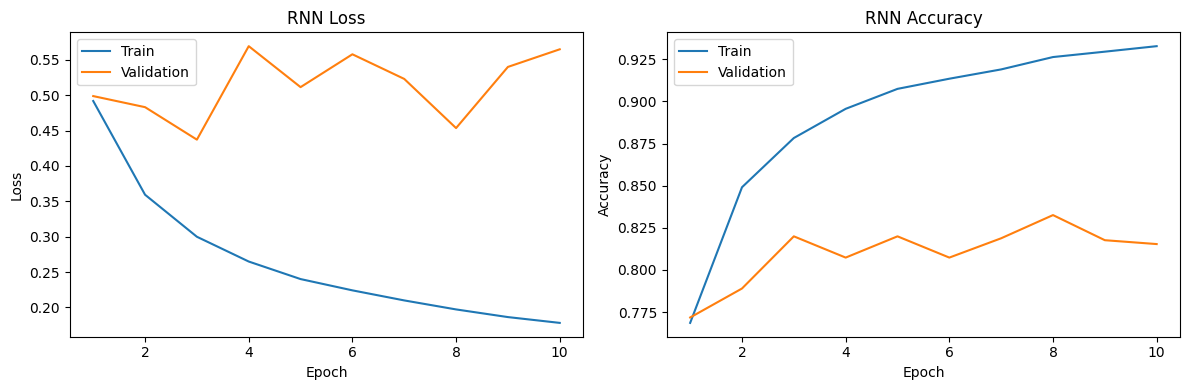

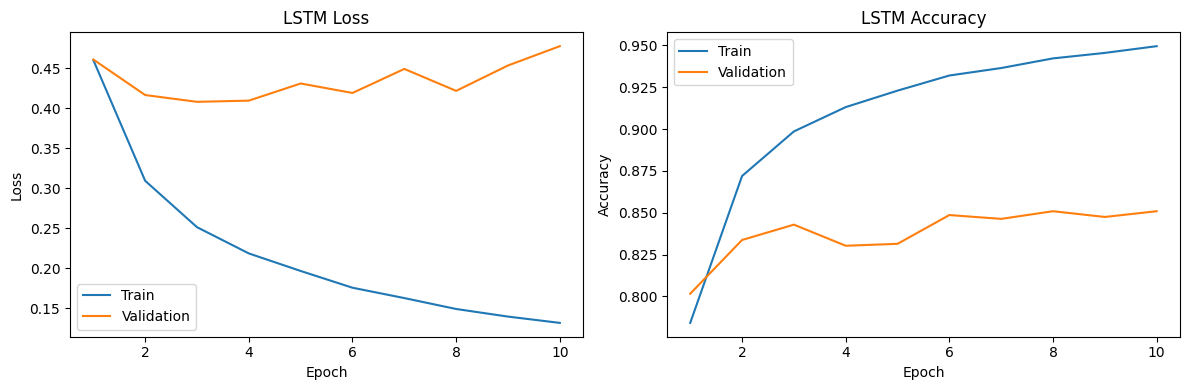

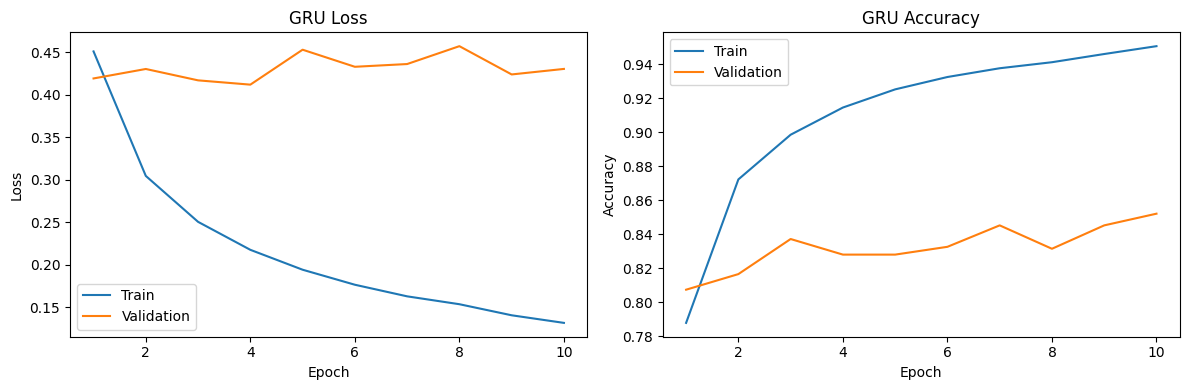

In [ ]:
epochs = range(1, EPOCHS + 1)

for model_type in ["RNN", "LSTM", "GRU"]:
    history = sentiment_history[model_type]

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history["train_loss"], label="Train")
    plt.plot(epochs, history["val_loss"], label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{model_type} Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, history["train_acc"], label="Train")
    plt.plot(epochs, history["val_acc"], label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{model_type} Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.show()

In [ ]:
comparison_rows = []

for model_type in ["RNN", "LSTM", "GRU"]:
    history = sentiment_history[model_type]
    model = sentiment_models[model_type]

    comparison_rows.append({
        "Architecture": model_type,
        "Final Validation Accuracy": history["val_acc"][-1],
        "Average Time per Epoch (s)": np.mean(history["epoch_time"]),
        "Total Parameters": count_parameters(model)
    })

sentiment_results = pd.DataFrame(comparison_rows)

sentiment_results

,Architecture,Final Validation Accuracy,Average Time per Epoch (s),Total Parameters
0,RNN,0.815367,31.424780,675689
1,LSTM,0.850917,31.503434,697961
2,GRU,0.852064,31.421086,690537


In [ ]:
display_table = sentiment_results.copy()

display_table["Final Validation Accuracy"] = (
    display_table["Final Validation Accuracy"] * 100
).round(2)

display_table["Average Time per Epoch (s)"] = (
    display_table["Average Time per Epoch (s)"].round(2)
)

display_table

,Architecture,Final Validation Accuracy,Average Time per Epoch (s),Total Parameters
0,RNN,81.54,31.42,675689
1,LSTM,85.09,31.50,697961
2,GRU,85.21,31.42,690537


### Extension
Using the final hidden state is suitable for sentence-level sentiment classification because the goal is to produce one label for the entire sentence. The recurrent network processes the sequence and the final hidden representation summarizes information from the complete input, which can then be passed to a binary classifier.
For token-level tasks such as part-of-speech tagging, one prediction is required for every token rather than for the complete sentence. Therefore, using only the final hidden state would discard the token-specific representations. Instead, the recurrent layer should return the hidden state at every time step, and a linear classification layer should be applied separately to each hidden state to produce one label per token.

1958-03-29    316.100006
1958-04-05    317.299988
1958-04-12    317.600006
1958-04-19    317.500000
1958-04-26    316.399994
Freq: W-SAT, Name: co2, dtype: float32
Number of observations: 2284


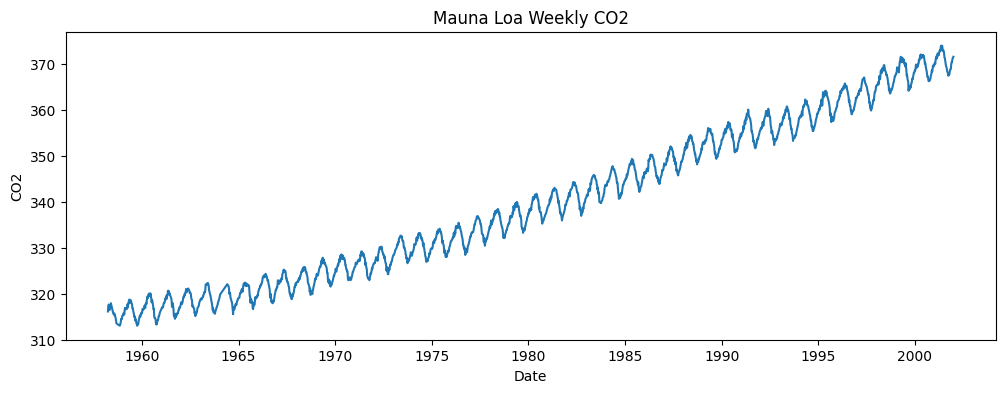

In [ ]:
co2 = sm.datasets.co2.load_pandas().data["co2"]

co2 = co2.interpolate(limit_direction="both").astype(np.float32)

print(co2.head())
print("Number of observations:", len(co2))

plt.figure(figsize=(12, 4))
plt.plot(co2.index, co2.values)
plt.xlabel("Date")
plt.ylabel("CO2")
plt.title("Mauna Loa Weekly CO2")
plt.show()

In [ ]:
values = co2.values.reshape(-1, 1)

n = len(values)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

scaler = StandardScaler()
scaler.fit(values[:train_end])

scaled_values = scaler.transform(values).flatten()

train_values = scaled_values[:train_end]
val_values = scaled_values[train_end:val_end]
test_values = scaled_values[val_end:]

print("Train:", len(train_values))
print("Validation:", len(val_values))
print("Test:", len(test_values))

Train: 1598
Validation: 343
Test: 343


In [ ]:
def make_sequences(values, lookback, horizon):
    x = []
    y = []

    for i in range(len(values) - lookback - horizon + 1):
        x.append(values[i:i + lookback])
        y.append(values[i + lookback:i + lookback + horizon])

    x = np.array(x, dtype=np.float32)
    y = np.array(y, dtype=np.float32)

    x = x[..., None]

    return torch.tensor(x), torch.tensor(y)


def make_time_loaders(lookback, horizon, batch_size=64):
    x_train, y_train = make_sequences(
        train_values,
        lookback,
        horizon
    )

    x_val, y_val = make_sequences(
        val_values,
        lookback,
        horizon
    )

    x_test, y_test = make_sequences(
        test_values,
        lookback,
        horizon
    )

    train_loader = DataLoader(
        TensorDataset(x_train, y_train),
        batch_size=batch_size,
        shuffle=True
    )

    val_loader = DataLoader(
        TensorDataset(x_val, y_val),
        batch_size=batch_size,
        shuffle=False
    )

    test_loader = DataLoader(
        TensorDataset(x_test, y_test),
        batch_size=batch_size,
        shuffle=False
    )

    return train_loader, val_loader, test_loader

In [ ]:
class LSTMForecaster(nn.Module):
    def __init__(self, horizon, hidden_size=64):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, horizon)

    def forward(self, x):
        _, (hidden, _) = self.lstm(x)

        return self.fc(hidden[-1])

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()

        position = torch.arange(max_len).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2)
            * (-np.log(10000.0) / d_model)
        )

        pe = torch.zeros(max_len, d_model)

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

In [ ]:
class TransformerForecaster(nn.Module):
    def __init__(
        self,
        horizon,
        d_model=32,
        nhead=4,
        num_layers=2
    ):
        super().__init__()

        self.input_projection = nn.Linear(1, d_model)

        self.position = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=64,
            dropout=0.1,
            activation="gelu",
            batch_first=True
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.fc = nn.Linear(d_model, horizon)

    def forward(self, x):
        x = self.input_projection(x)
        x = self.position(x)
        x = self.encoder(x)

        return self.fc(x[:, -1])

In [ ]:
def evaluate_forecaster(model, loader, criterion):
    model.eval()

    total_loss = 0
    total_samples = 0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            predictions = model(x)
            loss = criterion(predictions, y)

            total_loss += loss.item() * x.size(0)
            total_samples += x.size(0)

    return total_loss / total_samples


def train_forecaster(model, train_loader, val_loader, epochs=10):
    model = model.to(device)

    criterion = nn.MSELoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=0.001,
        weight_decay=1e-4
    )

    best_val_loss = float("inf")
    best_state = None

    epoch_times = []

    for epoch in range(epochs):
        model.train()

        start = time.perf_counter()

        for x, y in train_loader:
            x = x.to(device)
            y = y.to(device)

            optimizer.zero_grad()

            predictions = model(x)
            loss = criterion(predictions, y)

            loss.backward()
            optimizer.step()

        val_loss = evaluate_forecaster(
            model,
            val_loader,
            criterion
        )

        elapsed = time.perf_counter() - start
        epoch_times.append(elapsed)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)

    return model, np.mean(epoch_times)

In [ ]:
def get_predictions(model, loader):
    model.eval()

    predictions = []
    targets = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)

            pred = model(x)

            predictions.append(pred.cpu().numpy())
            targets.append(y.numpy())

    predictions = np.concatenate(predictions)
    targets = np.concatenate(targets)

    return predictions, targets


def inverse_scale(x):
    shape = x.shape

    x = scaler.inverse_transform(
        x.reshape(-1, 1)
    )

    return x.reshape(shape)

In [ ]:
LOOKBACKS = [24, 52]
HORIZONS = [1, 4, 12]

TS_EPOCHS = 10

forecast_results = []
forecast_outputs = {}

for lookback in LOOKBACKS:
    for horizon in HORIZONS:

        print(
            f"\nLookback={lookback}, Horizon={horizon}"
        )

        train_ts_loader, val_ts_loader, test_ts_loader = (
            make_time_loaders(
                lookback,
                horizon
            )
        )

        for model_name in ["LSTM", "Transformer"]:

            set_seed()

            if model_name == "LSTM":
                model = LSTMForecaster(
                    horizon=horizon,
                    hidden_size=64
                )
            else:
                model = TransformerForecaster(
                    horizon=horizon
                )

            model, avg_time = train_forecaster(
                model,
                train_ts_loader,
                val_ts_loader,
                epochs=TS_EPOCHS
            )

            pred_scaled, target_scaled = get_predictions(
                model,
                test_ts_loader
            )

            predictions = inverse_scale(pred_scaled)
            targets = inverse_scale(target_scaled)

            mae = np.mean(
                np.abs(predictions - targets)
            )

            rmse = np.sqrt(
                np.mean((predictions - targets) ** 2)
            )

            params = count_parameters(model)

            forecast_results.append({
                "Model": model_name,
                "Lookback": lookback,
                "Horizon": horizon,
                "MAE": mae,
                "RMSE": rmse,
                "Average Time per Epoch": avg_time,
                "Parameters": params
            })

            forecast_outputs[
                (model_name, lookback, horizon)
            ] = (predictions, targets)

            print(
                f"{model_name}: "
                f"MAE={mae:.3f}, "
                f"RMSE={rmse:.3f}"
            )


Lookback=24, Horizon=1
LSTM: MAE=6.106, RMSE=6.501
Transformer: MAE=9.510, RMSE=10.001

Lookback=24, Horizon=4
LSTM: MAE=8.214, RMSE=8.674
Transformer: MAE=13.775, RMSE=14.254

Lookback=24, Horizon=12
LSTM: MAE=10.828, RMSE=11.262
Transformer: MAE=15.498, RMSE=15.939

Lookback=52, Horizon=1
LSTM: MAE=5.857, RMSE=6.197
Transformer: MAE=10.193, RMSE=10.629

Lookback=52, Horizon=4
LSTM: MAE=6.382, RMSE=6.808
Transformer: MAE=14.272, RMSE=14.772

Lookback=52, Horizon=12
LSTM: MAE=12.261, RMSE=12.677
Transformer: MAE=15.766, RMSE=16.208


In [ ]:
forecast_df = pd.DataFrame(forecast_results)

forecast_df = forecast_df.sort_values(
    ["Lookback", "Horizon", "Model"]
).reset_index(drop=True)

forecast_df

,Model,Lookback,Horizon,MAE,RMSE,Average Time per Epoch,Parameters
0,LSTM,24,1,6.106191,6.501007,0.083744,17217
1,Transformer,24,1,9.509612,10.001097,0.168440,17185
2,LSTM,24,4,8.214398,8.674197,0.066599,17412
3,Transformer,24,4,13.775141,14.254384,0.154568,17284
4,LSTM,24,12,10.827605,11.261613,0.065275,17932
5,Transformer,24,12,15.498055,15.939251,0.156471,17548
6,LSTM,52,1,5.856747,6.197041,0.065351,17217
7,Transformer,52,1,10.192596,10.628975,0.162152,17185
8,LSTM,52,4,6.382191,6.807568,0.091928,17412
9,Transformer,52,4,14.271742,14.771534,0.189662,17284


In [ ]:
comparison = forecast_df.pivot_table(
    index=["Lookback", "Horizon"],
    columns="Model",
    values="RMSE"
)

comparison["Winner"] = np.where(
    comparison["LSTM"] < comparison["Transformer"],
    "LSTM",
    "Transformer"
)

comparison

Model                  LSTM  Transformer Winner
Lookback Horizon                               
24       1         6.501007    10.001097   LSTM
         4         8.674197    14.254384   LSTM
         12       11.261613    15.939251   LSTM
52       1         6.197041    10.628975   LSTM
         4         6.807568    14.771534   LSTM
         12       12.676767    16.208118   LSTM

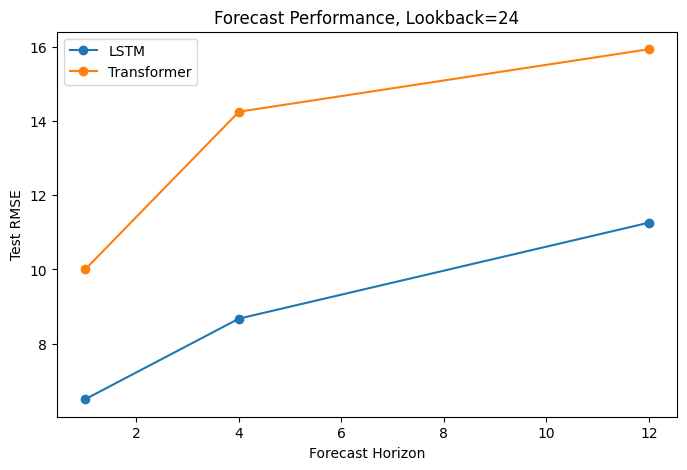

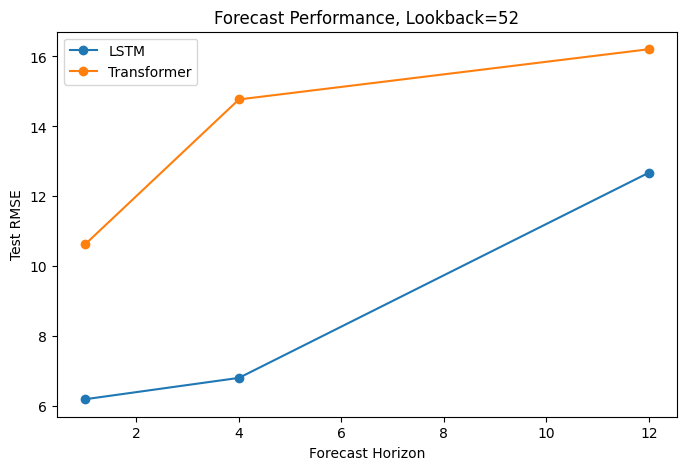

In [ ]:
for lookback in LOOKBACKS:

    plt.figure(figsize=(8, 5))

    subset = forecast_df[
        forecast_df["Lookback"] == lookback
    ]

    for model_name in ["LSTM", "Transformer"]:

        part = subset[
            subset["Model"] == model_name
        ]

        plt.plot(
            part["Horizon"],
            part["RMSE"],
            marker="o",
            label=model_name
        )

    plt.xlabel("Forecast Horizon")
    plt.ylabel("Test RMSE")
    plt.title(f"Forecast Performance, Lookback={lookback}")
    plt.legend()
    plt.show()

In [ ]:
print("Average RMSE by lookback")

display(
    forecast_df.groupby(
        ["Model", "Lookback"]
    )["RMSE"].mean().round(3)
)

print("\nAverage RMSE by forecast horizon")

display(
    forecast_df.groupby(
        ["Model", "Horizon"]
    )["RMSE"].mean().round(3)
)

Average RMSE by lookback


Model        Lookback
LSTM         24           8.812
             52           8.560
Transformer  24          13.398
             52          13.870
Name: RMSE, dtype: float32


Average RMSE by forecast horizon


Model        Horizon
LSTM         1           6.349000
             4           7.741000
             12         11.969000
Transformer  1          10.315000
             4          14.513000
             12         16.073999
Name: RMSE, dtype: float32

In [ ]:
best_row = forecast_df.loc[
    forecast_df["RMSE"].idxmin()
]

best_model_name = best_row["Model"]
best_lookback = int(best_row["Lookback"])
best_horizon = int(best_row["Horizon"])

print("Best configuration")
print("Model:", best_model_name)
print("Lookback:", best_lookback)
print("Horizon:", best_horizon)
print("RMSE:", round(best_row["RMSE"], 3))

Best configuration
Model: LSTM
Lookback: 52
Horizon: 1
RMSE: 6.197


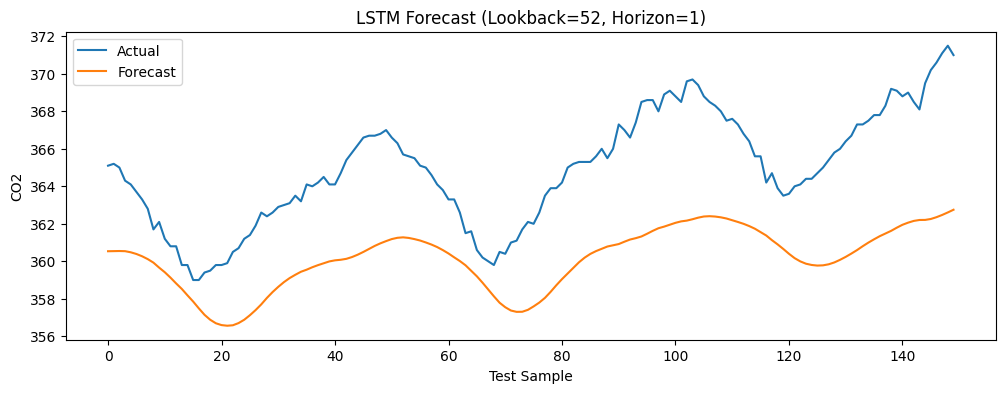

In [ ]:
key = (
    best_model_name,
    best_lookback,
    best_horizon
)

predictions, targets = forecast_outputs[key]

n_show = min(150, len(predictions))

plt.figure(figsize=(12, 4))

plt.plot(
    targets[:n_show, 0],
    label="Actual"
)

plt.plot(
    predictions[:n_show, 0],
    label="Forecast"
)

plt.xlabel("Test Sample")
plt.ylabel("CO2")
plt.title(
    f"{best_model_name} Forecast "
    f"(Lookback={best_lookback}, Horizon={best_horizon})"
)

plt.legend()
plt.show()